In [ ]:
####################################
#ENVIRONMENT SETUP

In [ ]:
#LIBRARIES

#system
import os
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"
import sys

#math and array operations
import numpy as np
import math

#plotting
import matplotlib
# matplotlib.use("Agg") #UNCOMMENT IF PLOTTING WITHIN JUPYTER DOCUMENT
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import TwoSlopeNorm

import cartopy.crs as ccrs
import cartopy.feature as cfeature

#data classes
import xarray as xr
import h5py
import pickle 

#loading bar
from tqdm import tqdm

#dates
from datetime import datetime

In [ ]:
#Importing DirectoryManager Class
sys.path.append(os.path.join("/glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/CodeFiles/","DataAnalysis"))
from CLASSES_Directories import DirectoryManager_Class

In [ ]:
DirectoryManager = DirectoryManager_Class()

codeType = os.path.join("DataAnalysis", "MPAS_Model_Data", "VariableComparisons")
# dataType = "UpdraftAreaAverages_HydrometeorConditions"
dataType = "UpdraftAreaAverages_PositiveReflectivity_Interpolation" #*INTERPOLATION

outputDirectory = DirectoryManager.GetOutputDirectory(codeType, dataType)
outputPlottingDirectory = DirectoryManager.GetOutputPlottingDirectory(codeType, dataType)

In [ ]:
#Importing ModelData Class
sys.path.append(os.path.join(DirectoryManager.mainCodeDirectory,"DataAnalysis","MPAS_Model_Data"))
from CLASSES_ModelData import StructuredModelData_Class, DataOperator_Class

In [37]:
#Setup

Region = "TRACER"; Case = "WET"; spinup_hours = "0"
# Region = "TRACER"; Case = "DIURNAL"; spinup_hours = "-5"
# Region = "PRECIP"; Case = "WET"; spinup_hours = "12"
# Region = "PRECIP"; Case = "DIURNAL"; spinup_hours = "12"

# Region = "Hawaii"; Case = "WET"; spinup_hours = "12"#;spinup_hours="-16"
# Region = "Hawaii"; Case = "TRADES"; spinup_hours = "24" 

In [38]:
#Load Model Directory Class
RunType = (Region,Case,"NSSL",spinup_hours)
ModelData = StructuredModelData_Class(DirectoryManager.mainDirectory, DirectoryManager.scratchDirectory, RunType)

# RunType = (Region,Case,"TEMPO",spinup_hours)
# ModelData_TEMPO = StructuredModelData_Class(DirectoryManager.mainDirectory, DirectoryManager.scratchDirectory, RunType)

Found 193/193 files matching expected times.
Opened history file: /glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/MPAS_Atmosphere_8.3.0/TRACER/WET/MPAS-Model_NSSL/model_run_spinup0hrs/history_cartesian/history.2022-07-01_00.00.00.latlon.nc
Opened diag file: /glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/MPAS_Atmosphere_8.3.0/TRACER/WET/MPAS-Model_NSSL/model_run_spinup0hrs/diag_cartesian/diag.2022-07-01_00.00.00.latlon.nc

=== MPAS Structured (lat-lon) Model Data Summary ===
 Region:         TRACER
 Case:           WET
 Microphysics:   NSSL
 Resolution:     20-1km
 Time Step:      15mins
 Time Range:     2022-07-01 to 2022-07-03
 Coordinates:    ['latitude', 'longitude', 'nVertLevels', 'nVertLevelsP1']
 # History Files:193
 # Diag Files:   193
 # Time Steps:   193
 Data Directory: /glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/MPAS_Atmosphere_8.3.0/TRACER/WET/MPAS-Model_NSSL/model_run_spinup0hrs
 Static File:    TRACER_regional5250_scaled3_

In [39]:
#Importing ModelData Class
sys.path.append(os.path.join(DirectoryManager.mainCodeDirectory,"DataAnalysis"))
from CLASSES_DataSaving import DataSaving_Class

In [40]:
#Importing PlottingModelData Class
sys.path.append(os.path.join(DirectoryManager.mainCodeDirectory,"DataAnalysis","MPAS_Model_Data"))
from CLASSES_PlottingModelData import RadarPlotting_Class

In [41]:
#Importing Radar Classes
sys.path.append(os.path.join(DirectoryManager.mainCodeDirectory,"DataAnalysis","Observation_Data"))
from CLASSES_RadarDataLoading import RadarData_MRMS_Class, RadarObservationMask_Class

sys.path.append(os.path.join(DirectoryManager.mainCodeDirectory,"DataAnalysis"))
from CLASSES_RadarDataPlotting import RadarPlotting_Class

In [42]:
#IMPORT FUNCTIONS
# --- Add your Functions folder to sys.path ---
import sys
path = os.path.join(DirectoryManager.mainCodeDirectory, 'Functions_2.0')
sys.path.append(path)


# --- Import all your function modules ---
import importlib
modules = [
    "AreaAverageFunctions",
    "ComputationFunctions",
    "DataFunctions",
    "DerivativeFunctions",
    "PlottingFunctions",
    "StatisticalFunctions",
]
for mod in modules:
    globals()[mod] = importlib.import_module(mod)        # import module itself
    globals().update(vars(globals()[mod]))              # import all functions into global namespace

In [43]:
###############
#JOB ARRAY SETUP

In [44]:
#Importing PlottingModelData Class
sys.path.append(os.path.join(DirectoryManager.mainCodeDirectory,"DataAnalysis"))
from CLASSES_JobArray import JobArray_Class

In [45]:
#JOB ARRAY SETUP
UsingJobArray=True

def GetNumJobs():
    num_jobs=20
    return num_jobs

num_jobs = GetNumJobs()
JobArray = JobArray_Class(total_elements=ModelData.Ntime, num_jobs=num_jobs, UsingJobArray=UsingJobArray)
start_job = JobArray.start_job; end_job = JobArray.end_job

def GetLoopElements(start_job,end_job):
    loop_elements = np.arange(ModelData.Ntime)[start_job:end_job].tolist()
    return loop_elements
loop_elements = GetLoopElements(start_job,end_job)

Running timesteps from 0:9 



In [46]:
####################################
#CALCULATION FUNCTIONS

In [47]:
def InitiateMatrix(variableSubset, fill_nan=False):
    """
    Initializes an output matrix for a given variable subset.
    """
    if "nVertLevels" in variableSubset.dims:
        shape = (ModelData.Ntime, ModelData.Nzc)

    elif "nVertLevelsP1" in variableSubset.dims:
        shape = (ModelData.Ntime, ModelData.Nzf)

    else:  # 2D variable case
        shape = (ModelData.Ntime, 1)

    fill_value = np.nan if fill_nan else 0
    output = np.full(shape, fill_value, dtype=float)

    return output

def GetMean(variableSubset):
    #(1/A) times integral of phi dA 
    #dA is [(R*cos(Lat)dLon)][RdLat] = R^2 cos(Lat)dLatdLon ==> weight is simply cos(Lat)
    weights = np.cos(np.deg2rad(variableSubset.latitude))
    variableMean = variableSubset.weighted(weights).mean(
        dim=("latitude", "longitude"),
        skipna=True
    )
    return variableMean

def MeanDBZ(variableSubset):
    # Convert from dBZ → linear Z (mm^6 m^-3)
    variableSubset_power = 10 ** (variableSubset / 10.0)

    # Take mean in linear space
    variableMean = GetMean(variableSubset_power)

    # Convert mean Z → back to dBZ
    variableMean = 10.0 * np.log10(variableMean)

    return variableMean

In [48]:
#Loading Radar Mask
RadarDataMask = RadarObservationMask_Class.LoadMaskData(DirectoryManager, ModelData)

Loaded mask: /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/OUTPUT/DataAnalysis/Observation_Data/RadarData/RadarObservationMask/TRACER_WET_spinup0hrs/RadarObservationMask.nc



In [49]:
####################################
#CALCULATION FUNCTIONS

In [50]:
def CalculateCondensateThreshold(ModelData,t,
                                 qt_min=15):
    # data = ModelData.GetDataTimestep(t)
    # qt = data['qc'] + data['qi']
    data = ModelData.GetDataTimestep_diag(t)
    qt = data['refl10cm']
    qtMask = qt > qt_min
    return qtMask

def CalculateHydrometeorThreshold(ModelData,t, #these functions are the same in this version
                                 qt_min=15):
    # data = ModelData.GetDataTimestep(t)
    # qt = data['qr'] + data['qg']
    data = ModelData.GetDataTimestep_diag(t)
    qt = data['refl10cm']
    qtMask = qt > qt_min
    return qtMask

In [51]:
def GetVariableSubset_Helper(ModelData, dataSubset, dataSubset_diag, dataSubset_static, varName):
    """
    Retrieves a variable subset from the given model data.
    If varName contains a '+', returns the sum of the two variables.
    """
    if '+' in varName:
        var1, var2 = varName.split('+')
        var1 = var1.strip()
        var2 = var2.strip()

        subset1 = DataOperator_Class.GetData_Variable(ModelData, dataSubset, 
                                                      dataSubset_diag, dataSubset_static, var1)
        subset2 = DataOperator_Class.GetData_Variable(ModelData, dataSubset, 
                                                      dataSubset_diag, dataSubset_static, var2)
        variableSubset = subset1 + subset2
    else:
        variableSubset = DataOperator_Class.GetData_Variable(ModelData, dataSubset, 
                                                             dataSubset_diag, dataSubset_static, varName)

    return variableSubset

def InterpolateWToCenters_Indexes(wData):
    wData_center = 0.5 * (
        wData.isel(nVertLevelsP1=slice(0, -1)) +
        wData.isel(nVertLevelsP1=slice(1, None))
    )
    wData_center = wData_center.rename({"nVertLevelsP1": "nVertLevels"})
    return wData_center

def InterpolateWToCenters_PhysicalZ(wData):
    """
    Convert interface w (nVertLevelsP1, physical z)
    to center w (nVertLevels, physical z centers),
    using index-based averaging to avoid xarray alignment.
    """

    if "nVertLevelsP1" not in wData.dims:
        raise ValueError("Expected dimension 'nVertLevelsP1'")

    # --- raw data (index-based arithmetic, no alignment) ---
    wLower = wData.isel(nVertLevelsP1=slice(0, -1)).data
    wUpper = wData.isel(nVertLevelsP1=slice(1, None)).data
    wCenter = 0.5 * (wLower + wUpper)

    # --- physical z centers from interface z ---
    zInterface = wData["nVertLevelsP1"].values   # physical z at interfaces
    zCenter = 0.5 * (zInterface[:-1] + zInterface[1:])

    # --- build DataArray with physical z preserved ---
    wData_center = xr.DataArray(
        wCenter,
        dims=("nVertLevels", "latitude", "longitude"),
        coords={
            "nVertLevels": zCenter,        # <-- physical z centers
            "latitude": wData.latitude,
            "longitude": wData.longitude,
        },
        name=wData.name,
        attrs=wData.attrs,
    )

    return wData_center


In [52]:
def RunCalculations(ModelData, varNames, loop_elements,zTarget=None):
    # wthresh_updraft = 0.1; wthresh_downdraft = -0.1 #*NEW
    wthresh_updraft = 0.5; wthresh_downdraft = -0.5 #*NEW
    
    outputDictionary={}
    for count, t in enumerate(tqdm(loop_elements, desc="Processing timesteps")):
        # if t % 10 == 0: print(f"Currently working on time {t}/{num_times}","\n")
            
        #Loading Data
        [dataSubset,dataSubset_diag,dataSubset_static, lat,lon,zGrid_f,zGrid_c, _, _] = DataOperator_Class.GetData_Subset(ModelData, t)
        
        #Loading W for Later Subsetting
        wSubset_f= GetVariableSubset_Helper(ModelData, dataSubset, dataSubset_diag, dataSubset_static, "w") #*NEW
        #Interpolating Z levels #*INTERPOLATION
        #################################
        if any(dim.startswith("nVertLevels") for dim in wSubset_f.dims):
            if zTarget is None:
                [zTarget_f, zTarget_c] = ModelData.GetZTarget(zGrid_f, zGrid_c)
                zTarget = "loaded"
            wSubset_f = ModelData.InterpolateVertical(wSubset_f,zGrid_f,zGrid_c,zTarget_f,zTarget_c)
        #################################
        # wSubset_c = InterpolateWToCenters_Indexes(wSubset_f) #use if not interpolating
        wSubset_c = InterpolateWToCenters_PhysicalZ(wSubset_f) #*INTERPOLATION
        wSubset_c = wSubset_c.where(RadarDataMask == True) #*NEW

        #THRESHOLD THINGS
        wUpdraftThreshold_c = wSubset_c > wthresh_updraft
        wDowndraftThreshold_c  = wSubset_c < wthresh_downdraft
        wUpdraftThreshold_f = wSubset_f > wthresh_updraft
        wDowndraftThreshold_f  = wSubset_f < wthresh_downdraft
        condensateMask = CalculateCondensateThreshold(ModelData, t) #*NEW
        condensateMask = ModelData.InterpolateVertical(condensateMask,zGrid_f,zGrid_c,zTarget_f,zTarget_c) #*NEW
        hydrometeorMask = CalculateHydrometeorThreshold(ModelData, t) #*NEW
        hydrometeorMask = ModelData.InterpolateVertical(hydrometeorMask,zGrid_f,zGrid_c,zTarget_f,zTarget_c) #*NEW
    
        for varName in varNames:
            if count == 0: print(f"Running for {varName}")
                
            #Subsetting Data
            if varName in ["w"]:
                # variableSubset = wSubset_f.copy(deep=True)
                variableSubset = wSubset_c.copy(deep=True) #*INTERPOLATE W TO CENTERS (WHEN USING condensate/hydrometeor THRESHOLDS)
            else:
                variableSubset= GetVariableSubset_Helper(ModelData, dataSubset, dataSubset_diag, dataSubset_static, varName)

                #Interpolating Z levels #*INTERPOLATION
                #################################
                if any(dim.startswith("nVertLevels") for dim in variableSubset.dims):
                    variableSubset = ModelData.InterpolateVertical(variableSubset,zGrid_f,zGrid_c,zTarget_f,zTarget_c)
                #################################

            if varName in ['refl10cm','refl10cm_1km']:
                variableSubset = variableSubset.where(variableSubset > 0)

            #Applying RadarDataMask
            variableSubset = variableSubset.where(RadarDataMask == True)

            #Applying Updraft/Downdraft Thresholds #*NEW
            # wUpdraftThreshold = wUpdraftThreshold_f if varName in ["w"] else wUpdraftThreshold_c
            # wDowndraftThreshold = wDowndraftThreshold_f if varName in ["w"] else wDowndraftThreshold_c
            wUpdraftThreshold = wUpdraftThreshold_c #*INTERPOLATE W TO CENTERS (WHEN USING condensate/hydrometeor THRESHOLDS)
            wDowndraftThreshold = wDowndraftThreshold_c #*INTERPOLATE W TO CENTERS (WHEN USING condensate/hydrometeor THRESHOLDS)
            variableSubset_Updraft = variableSubset.where(wUpdraftThreshold==True).where(condensateMask==True) #*NEW
            variableSubset_Downdraft = variableSubset.where(wDowndraftThreshold==True).where(hydrometeorMask==True) #*NEW

            #Initializing Output
            if count == 0:
                output_Updraft = InitiateMatrix(variableSubset, fill_nan=False) #*NEW
                outputDictionary[f"{varName}_updraft"] = output_Updraft
                output_Downdraft = InitiateMatrix(variableSubset, fill_nan=False) #*NEW
                outputDictionary[f"{varName}_downdraft"] = output_Downdraft                

            #Taking Mean
            if varName in ['refl10cm','refl10cm_1km']:
                variableMean_Updraft = MeanDBZ(variableSubset_Updraft) #*NEW
                variableMean_Downdraft = MeanDBZ(variableSubset_Downdraft) #*NEW
            else:
                variableMean_Updraft = GetMean(variableSubset_Updraft) #*NEW
                variableMean_Downdraft = GetMean(variableSubset_Downdraft) #*NEW
                
            outputDictionary[f"{varName}_updraft"][t] = variableMean_Updraft #*NEW
            outputDictionary[f"{varName}_downdraft"][t] = variableMean_Downdraft #*NEW
    return outputDictionary

def GetData_Subset(ModelData,t):  
    data = ModelData.GetDataTimestep(t,printout=False)
    data_diag = ModelData.GetDataTimestep_diag(t,printout=False)
    
    [latCenter,lonCenter] = DataOperator_Class.LatLonBoundingBox_Center(region=ModelData.region)
    [latBounds, lonBounds] = DataOperator_Class.LatLonBoundingBox_Calculation(latCenter, lonCenter, radius_km=500)
    dataSubset, lat, lon = DataOperator_Class.LatLonBoundingBox_Subset(data,latBounds, lonBounds)
    dataSubset_diag, _, _ = DataOperator_Class.LatLonBoundingBox_Subset(data_diag,latBounds, lonBounds)
    dataSubset_static, _, _ = DataOperator_Class.LatLonBoundingBox_Subset(ModelData.staticData,latBounds, lonBounds)

    # Lon, Lat = np.meshgrid(lon, lat) #not actually needed to plot
    return dataSubset, dataSubset_diag, dataSubset_static, lat, lon, data, data_diag

In [53]:
def RunAreaAverages(ModelData,varNames,name, loop_elements):
    filePath = DataOperator_Class.GetOutputFilePath(ModelData, DirectoryManager, outputDirectory, fileName = f"outputDictionary_{name}_{loop_elements[0]}-{loop_elements[-1]+1}.h5")
    
    #loading back in 
    try:
        #loading output
        print("\n")
        outputDictionary = DataSaving_Class.LoadDictionaryFromH5(filePath)
        return outputDictionary
    except Exception as e:
        print(f"Error: {e}")
        
        print("Running Calculation")
        outputDictionary = RunCalculations(ModelData, varNames, loop_elements) #takes about 10 minutes
        #saving output
        print("\n")
        DataSaving_Class.SaveDictionaryToH5(outputDictionary, filePath)
        return outputDictionary

In [54]:
####################################
#CALCULATING FUNCTIONS

In [55]:
def GetDictionary_2(ModelData, loop_elements):
    #3D Variables (9 vars)
    #microphysics variables
    varNames = ["qv", "qc+qi", "qr", "qg", "qs"]
    #convection variables
    varNames += ["w"]
    
    outputDictionary = RunAreaAverages(ModelData,varNames,"2", loop_elements)
    return outputDictionary

In [56]:
def RunJob(loop_elements):
    
    #getting NSSL dictionaries
    RunType = (Region,Case,"NSSL",spinup_hours)
    ModelData = StructuredModelData_Class(DirectoryManager.mainDirectory, DirectoryManager.scratchDirectory, RunType, printSummary=False)
    
    outputDictionary_3D_NSSL = GetDictionary_2(ModelData, loop_elements)
    
    #getting TEMPO dictionaries
    RunType = (Region,Case,"TEMPO",spinup_hours)
    ModelData = StructuredModelData_Class(DirectoryManager.mainDirectory, DirectoryManager.scratchDirectory, RunType, printSummary=False)
    
    outputDictionary_3D_TEMPO = GetDictionary_2(ModelData, loop_elements)

    return outputDictionary_3D_NSSL,outputDictionary_3D_TEMPO

In [57]:
####################################
#CALCULATING
running = True #keep true when job_array is running
# running = False

In [58]:
if running:
    [outputDictionary_3D_NSSL,outputDictionary_3D_TEMPO] = RunJob(loop_elements)

Found 193/193 files matching expected times.
Opened history file: /glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/MPAS_Atmosphere_8.3.0/TRACER/WET/MPAS-Model_NSSL/model_run_spinup0hrs/history_cartesian/history.2022-07-01_00.00.00.latlon.nc
Opened diag file: /glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/MPAS_Atmosphere_8.3.0/TRACER/WET/MPAS-Model_NSSL/model_run_spinup0hrs/diag_cartesian/diag.2022-07-01_00.00.00.latlon.nc


Loaded 12 variables from /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/OUTPUT/DataAnalysis/MPAS_Model_Data/VariableComparisons/UpdraftAreaAverages_PositiveReflectivity_Interpolation/TRACER_WET_NSSL_0hrs/outputDictionary_2_0-10.h5
Found 193/193 files matching expected times.
Opened history file: /glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/MPAS_Atmosphere_8.3.0/TRACER/WET/MPAS-Model_TEMPO/model_run_spinup0hrs/history_cartesian/history.2022-07-01_00.00.00.latlon.nc
Opened diag file: /glade/derecho/scratch/ar

In [59]:
####################################
#RECOMBINING
recombining = False #keep false when job_array is running
# recombining = True

In [60]:
def AddDictionaries(dictA, dictB):
    """
    Modifies dictA by adding dictB values into it
    """
    for key in dictA:
        dictA[key] += dictB[key]
        
def Recombine():
    for job_id in tqdm(range(1, num_jobs + 1)):
    
        start_job, end_job = JobArray._get_job_range(job_id)
        loop_elements = GetLoopElements(start_job, end_job)
    
        dict3D_NSSL, dict3D_TEMPO = RunJob(loop_elements)
    
        if job_id == 1:
            dict3D_NSSL_all = dict3D_NSSL
            dict3D_TEMPO_all = dict3D_TEMPO
        else:
            AddDictionaries(dict3D_NSSL_all, dict3D_NSSL)
            AddDictionaries(dict3D_TEMPO_all,dict3D_TEMPO)
    return dict3D_NSSL_all,dict3D_TEMPO_all

In [61]:
if recombining:
    [outputDictionary_3D_NSSL,outputDictionary_3D_TEMPO] = Recombine()

  5%|▌         | 1/20 [00:00<00:02,  7.60it/s]

Found 193/193 files matching expected times.
Opened history file: /glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/MPAS_Atmosphere_8.3.0/TRACER/WET/MPAS-Model_NSSL/model_run_spinup0hrs/history_cartesian/history.2022-07-01_00.00.00.latlon.nc
Opened diag file: /glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/MPAS_Atmosphere_8.3.0/TRACER/WET/MPAS-Model_NSSL/model_run_spinup0hrs/diag_cartesian/diag.2022-07-01_00.00.00.latlon.nc


Loaded 12 variables from /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/OUTPUT/DataAnalysis/MPAS_Model_Data/VariableComparisons/UpdraftAreaAverages_PositiveReflectivity_Interpolation/TRACER_WET_NSSL_0hrs/outputDictionary_2_0-10.h5
Found 193/193 files matching expected times.
Opened history file: /glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/MPAS_Atmosphere_8.3.0/TRACER/WET/MPAS-Model_TEMPO/model_run_spinup0hrs/history_cartesian/history.2022-07-01_00.00.00.latlon.nc
Opened diag file: /glade/derecho/scratch/ar

 10%|█         | 2/20 [00:00<00:03,  4.74it/s]

Found 193/193 files matching expected times.
Opened history file: /glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/MPAS_Atmosphere_8.3.0/TRACER/WET/MPAS-Model_NSSL/model_run_spinup0hrs/history_cartesian/history.2022-07-01_00.00.00.latlon.nc
Opened diag file: /glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/MPAS_Atmosphere_8.3.0/TRACER/WET/MPAS-Model_NSSL/model_run_spinup0hrs/diag_cartesian/diag.2022-07-01_00.00.00.latlon.nc


Loaded 12 variables from /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/OUTPUT/DataAnalysis/MPAS_Model_Data/VariableComparisons/UpdraftAreaAverages_PositiveReflectivity_Interpolation/TRACER_WET_NSSL_0hrs/outputDictionary_2_10-20.h5
Found 193/193 files matching expected times.
Opened history file: /glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/MPAS_Atmosphere_8.3.0/TRACER/WET/MPAS-Model_TEMPO/model_run_spinup0hrs/history_cartesian/history.2022-07-01_00.00.00.latlon.nc
Opened diag file: /glade/derecho/scratch/a

 15%|█▌        | 3/20 [00:00<00:03,  5.36it/s]

...

Found 193/193 files matching expected times.
Opened history file: /glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/MPAS_Atmosphere_8.3.0/TRACER/WET/MPAS-Model_TEMPO/model_run_spinup0hrs/history_cartesian/history.2022-07-01_00.00.00.latlon.nc
Opened diag file: /glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/MPAS_Atmosphere_8.3.0/TRACER/WET/MPAS-Model_TEMPO/model_run_spinup0hrs/diag_cartesian/diag.2022-07-01_00.00.00.latlon.nc


Loaded 12 variables from /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/OUTPUT/DataAnalysis/MPAS_Model_Data/VariableComparisons/UpdraftAreaAverages_PositiveReflectivity_Interpolation/TRACER_WET_TEMPO_0hrs/outputDictionary_2_148-157.h5
Found 193/193 files matching expected times.
Opened history file: /glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/MPAS_Atmosphere_8.3.0/TRACER/WET/MPAS-Model_NSSL/model_run_spinup0hrs/history_cartesian/history.2022-07-01_00.00.00.latlon.nc
Opened diag file: /glade/derecho/scrat

 90%|█████████ | 18/20 [00:02<00:00,  6.86it/s]

Found 193/193 files matching expected times.
Opened history file: /glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/MPAS_Atmosphere_8.3.0/TRACER/WET/MPAS-Model_NSSL/model_run_spinup0hrs/history_cartesian/history.2022-07-01_00.00.00.latlon.nc
Opened diag file: /glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/MPAS_Atmosphere_8.3.0/TRACER/WET/MPAS-Model_NSSL/model_run_spinup0hrs/diag_cartesian/diag.2022-07-01_00.00.00.latlon.nc


Loaded 12 variables from /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/OUTPUT/DataAnalysis/MPAS_Model_Data/VariableComparisons/UpdraftAreaAverages_PositiveReflectivity_Interpolation/TRACER_WET_NSSL_0hrs/outputDictionary_2_166-175.h5
Found 193/193 files matching expected times.
Opened history file: /glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/MPAS_Atmosphere_8.3.0/TRACER/WET/MPAS-Model_TEMPO/model_run_spinup0hrs/history_cartesian/history.2022-07-01_00.00.00.latlon.nc
Opened diag file: /glade/derecho/scratch

100%|██████████| 20/20 [00:03<00:00,  6.56it/s]

Found 193/193 files matching expected times.
Opened history file: /glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/MPAS_Atmosphere_8.3.0/TRACER/WET/MPAS-Model_TEMPO/model_run_spinup0hrs/history_cartesian/history.2022-07-01_00.00.00.latlon.nc
Opened diag file: /glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/MPAS_Atmosphere_8.3.0/TRACER/WET/MPAS-Model_TEMPO/model_run_spinup0hrs/diag_cartesian/diag.2022-07-01_00.00.00.latlon.nc


Loaded 12 variables from /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/OUTPUT/DataAnalysis/MPAS_Model_Data/VariableComparisons/UpdraftAreaAverages_PositiveReflectivity_Interpolation/TRACER_WET_TEMPO_0hrs/outputDictionary_2_175-184.h5
Found 193/193 files matching expected times.
Opened history file: /glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/MPAS_Atmosphere_8.3.0/TRACER/WET/MPAS-Model_NSSL/model_run_spinup0hrs/history_cartesian/history.2022-07-01_00.00.00.latlon.nc
Opened diag file: /glade/derecho/scrat

In [62]:
####################################
#PLOTTING FUNCTIONS

fontSettings = {
    "tickFont": 16-4,
    "labelFont": 18-4,
    "legendFont": 14-2,
    "titleFont": 22,
}

plotting = False #keep false when job array is running
# plotting = True

In [66]:
def GetVerticalCoord(dataSubset):
    pressure_profile = dataSubset['pressure'].mean(dim=("latitude","longitude")).data
    dp = pressure_profile[-1] - pressure_profile[-2]
    p_topface = pressure_profile[-1] + dp  # extrapolate linearly
    pressure_profile_face = np.append(pressure_profile, p_topface)
    return (pressure_profile/100,pressure_profile_face/100)

if plotting:
    [dataSubset,dataSubset_diag,dataSubset_static, lat,lon,zGrid_f,zGrid_c, _, _] = DataOperator_Class.GetData_Subset(ModelData, t=0)
    pressure_profiles = GetVerticalCoord(dataSubset)
    time_strings = ModelData.timeStrings
    time = [datetime.strptime(t, "%Y-%m-%d_%H.%M.%S") for t in time_strings]

In [67]:
#Helper Functions

# Example: align datetime x-limits to min/max of your data
def SetXLimitsDatetime(ax, time_array):
    """
    Ensures datetime x-axis starts and ends exactly at the first and last time values.
    Works for both datetime.datetime and np.datetime64 arrays.
    """
    import numpy as np
    from matplotlib.dates import date2num

    # Convert to Matplotlib’s internal float format if needed
    times = np.asarray(time_array)
    if np.issubdtype(times.dtype, np.datetime64):
        times = date2num(times)
    elif isinstance(times[0], (object,)):
        try:
            times = date2num(times)
        except Exception:
            pass

    ax.set_xlim(times.min(), times.max())

In [68]:
def variableLinePlot_Vertical(axis, output,zlevels_plot, varName, units, color, label):
    axis.plot(output.squeeze(),zlevels_plot, color=color, label=label)
    axis.set_xlabel(f"{varName} " + fr"$({units})$", fontsize=fontSettings["labelFont"])
    axis.set_ylabel("Altitude (km)", fontsize=fontSettings["labelFont"])
    axis.grid(True)

def variableLinePlot_Time(axis, time, output, varName, units, color, label):
    axis.plot(time, output.squeeze(), color=color, label=label)
    axis.set_ylabel(f"{varName} " + fr"$({units})$", fontsize=fontSettings["labelFont"])
    axis.set_xlabel("Time", fontsize=fontSettings["labelFont"])
    axis.grid(True)
    SetXLimitsDatetime(axis, time)
    axis.tick_params(axis="x", rotation=45)
    axis.legend(fontsize=fontSettings["legendFont"])
    axis.tick_params(axis="both", labelsize=fontSettings["tickFont"])

def FixAxisLabels_Contour(axis, varName, 
                          zlevels_plot):
    top = 2.0 if "qr" in varName else maxZLevel
    if ModelData.region=="Hawaii" and ModelData.case=="TRADES":
        top = 2.0 if "qr" in varName else maxZLevel    

    bottom = 0#np.min(zlevels_plot)
    axis.set_ylim(bottom,top)    
    
    axis.set_xlabel("Time", fontsize=fontSettings["labelFont"])
    axis.set_ylabel("Altitude (km)", fontsize=fontSettings["labelFont"])
    axis.tick_params(axis="x", rotation=45)
    axis.tick_params(axis="both", labelsize=fontSettings["tickFont"])

def FixAxisLabels_Line_Vertical(axis, varName,updowndraft,
                                zlevels_plot,
                                useTitle=True):
    top = 2.0 if "qr" in varName else maxZLevel
    if ModelData.region=="Hawaii" and ModelData.case=="TRADES":
        top = 2.0 if "qr" in varName else maxZLevel
        
    bottom = 0#np.min(zlevels_plot)
    axis.set_ylim(bottom,top)    

    if useTitle: axis.set_title(f"Vertical profiles ({updowndraft})")
    axis.set_ylabel("Altitude (km)", fontsize=fontSettings["labelFont"])
    axis.legend(fontsize=fontSettings["legendFont"])
    axis.tick_params(axis="both", labelsize=fontSettings["tickFont"])

In [69]:
# PlotUpdraftDowndraftPlots_V1

zGrid_f, zGrid_c = ModelData.GetZGrids() #*INTERPOLATION
[zTarget_f, zTarget_c] = ModelData.GetZTarget(zGrid_f, zGrid_c) #*INTERPOLATION

def PlotUpdraftDowndraftPlots_V1(varName='w',units="m/s",
                              multiplier=1,
                              num_levels=19):

    #Z AXIS
    z_levels_filePath = "/glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/MPAS_Atmosphere_8.3.1/TRACER/WET/MPAS-Model_8.3.1_56nz/zeta_30km_57levels.txt"
    zlevels = np.loadtxt(z_levels_filePath)/1e3
    zlevels_center = 0.5 * (zlevels[:-1] + zlevels[1:])
    if varName not in ['w']:
        # zlevels_plot = zlevels_center.copy()
        zlevels_plot = zTarget_c/1e3 #*INTERPOLATION
    else:
        # zlevels_plot = zlevels.copy()
        # zlevels_plot = zTarget_f/1e3 #*INTERPOLATION
        zlevels_plot = zTarget_c/1e3 #*INTERPOLATION #*(WHEN USING condensate/hydrometeor THRESHOLDS)
    
    fig, axes = plt.subplots(
        nrows=2, ncols=5,
        figsize=(18, 8),
        constrained_layout=True
    )
    fig.subplots_adjust(wspace=0.22,hspace=0.55)
    
    # =========================
    # ROW 1 — UPDRAFT
    # =========================
    updowndraft = "updraft"
    
    a = multiplier*outputDictionary_3D_NSSL[f"{varName}_{updowndraft}"]
    b = multiplier*outputDictionary_3D_TEMPO[f"{varName}_{updowndraft}"]
    c = a - b

    #Levels
    vmin = np.nanmin([np.nanmin(a), np.nanmin(b)])
    vmax = np.nanmax([np.nanmax(a), np.nanmax(b)])
    # levels = np.linspace(vmin,vmax,num_levels)
    levels = np.round(np.linspace(vmin,vmax,num_levels),3)
    diff_vlim = np.nanmax(np.abs(c))
    diff_levels = np.linspace(-diff_vlim, diff_vlim, num_levels)
    diff_norm = TwoSlopeNorm(vcenter=0.0, vmin=-diff_vlim, vmax=diff_vlim)


    #Plotting
    axis = axes[0, 0]
    cf1 = axis.contourf(time, zlevels_plot, a.T, levels=levels)
    axis.set_title("NSSL (updraft)")
    plt.colorbar(cf1, ax=axes[0, 0], pad=-0.05)
    FixAxisLabels_Contour(axis, varName,
                          zlevels_plot)

    axis = axes[0, 1] 
    cf2 = axis.contourf(time, zlevels_plot, b.T, levels=levels)
    axis.set_title("TEMPO (updraft)")
    plt.colorbar(cf2, ax=axes[0, 1], pad=-0.05)
    FixAxisLabels_Contour(axis, varName,
                          zlevels_plot)

    axis = axes[0, 2]
    cf3 = axis.contourf(time, zlevels_plot, c.T, levels=diff_levels,
                              cmap="RdBu_r", norm=diff_norm)
    axes[0, 2].set_title("NSSL − TEMPO (updraft)")
    plt.colorbar(cf3, ax=axes[0, 2], pad=-0.05)
    FixAxisLabels_Contour(axis, varName,
                          zlevels_plot)
    
    aMean_Vertical = np.nanmean(a, axis=0)
    bMean_Vertical = np.nanmean(b, axis=0)
    aMean_Time = np.nanmean(a, axis=1)
    bMean_Time = np.nanmean(b, axis=1)
    
    axis = axes[0, 3]
    variableLinePlot_Vertical(axis, aMean_Vertical,zlevels_plot, varName, units=units, color="blue", label="NSSL")
    variableLinePlot_Vertical(axis, bMean_Vertical,zlevels_plot, varName, units=units, color="green", label="TEMPO")
    # axis.axhline(1) #*INTERPOLATION 
    FixAxisLabels_Line_Vertical(axis, varName,"updraft",
                       zlevels_plot)

    aMean = np.nanmean(a, axis=1)
    bMean = np.nanmean(b, axis=1)
    
    axis = axes[0, 4]
    variableLinePlot_Time(axis, time, aMean_Time, varName, units=units, color="blue", label="NSSL")
    variableLinePlot_Time(axis, time, bMean_Time, varName, units=units, color="green", label="TEMPO")

    
    # =========================
    # ROW 2 — DOWNDRAFT
    # =========================
    updowndraft = "downdraft"
    
    a = multiplier*outputDictionary_3D_NSSL[f"{varName}_{updowndraft}"]
    b = multiplier*outputDictionary_3D_TEMPO[f"{varName}_{updowndraft}"]
    c = a - b

    #Levels
    vmin = np.nanmin([np.nanmin(a), np.nanmin(b)])
    vmax = np.nanmax([np.nanmax(a), np.nanmax(b)])
    # levels = np.linspace(vmin,vmax,num_levels)
    levels = np.round(np.linspace(vmin,vmax,num_levels),3)
    diff_vlim = np.nanmax(np.abs(c))
    diff_levels = np.linspace(-diff_vlim, diff_vlim, num_levels)
    diff_norm = TwoSlopeNorm(vcenter=0.0, vmin=-diff_vlim, vmax=diff_vlim)

    #Plotting
    axis = axes[1, 0]
    cf1 = axis.contourf(time, zlevels_plot, a.T, levels=levels)
    axis.set_title("NSSL (downdraft)")
    plt.colorbar(cf1, ax=axes[1, 0], pad=-0.05)
    FixAxisLabels_Contour(axis, varName,
                          zlevels_plot)

    axis = axes[1, 1]
    cf2 = axis.contourf(time, zlevels_plot, b.T, levels=levels)
    axis.set_title("TEMPO (downdraft)")
    plt.colorbar(cf2, ax=axes[1, 1], pad=-0.05)
    FixAxisLabels_Contour(axis, varName,
                          zlevels_plot)

    axis = axes[1, 2]
    cf3 = axis.contourf(time, zlevels_plot, c.T, levels=diff_levels,
                              cmap="RdBu_r",norm=diff_norm)
    axis.set_title("NSSL − TEMPO (downdraft)")
    plt.colorbar(cf3, ax=axes[1, 2], pad=-0.05)
    FixAxisLabels_Contour(axis, varName,
                          zlevels_plot)
    
    aMean_Vertical = np.nanmean(a, axis=0)
    bMean_Vertical = np.nanmean(b, axis=0)
    aMean_Time = np.nanmean(a, axis=1)
    bMean_Time = np.nanmean(b, axis=1)
    
    axis = axes[1, 3]
    variableLinePlot_Vertical(axis, aMean_Vertical,zlevels_plot, varName, units=units, color="blue", label="NSSL")
    variableLinePlot_Vertical(axis, bMean_Vertical,zlevels_plot, varName, units=units, color="green", label="TEMPO")
    FixAxisLabels_Line_Vertical(axis, varName,"downdraft",
                       zlevels_plot)
    axis = axes[1, 4]
    variableLinePlot_Time(axis, time, aMean_Time, varName, units=units, color="blue", label="NSSL")
    variableLinePlot_Time(axis, time, bMean_Time, varName, units=units, color="green", label="TEMPO")

    fig.suptitle(f"{ModelData.region} {ModelData.case}",y=1.05,fontweight='bold',fontsize=25)
    return fig

In [70]:
def PlotUpdraftDowndraftPlots_V2(varName='w', units="m/s",
                                multiplier=1,
                                num_levels=19):

    #Z AXIS
    z_levels_filePath = "/glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/MPAS_Atmosphere_8.3.1/TRACER/WET/MPAS-Model_8.3.1_56nz/zeta_30km_57levels.txt"
    zlevels = np.loadtxt(z_levels_filePath) / 1e3
    zlevels_center = 0.5 * (zlevels[:-1] + zlevels[1:])
    if varName not in ['w']:
        # zlevels_plot = zlevels_center.copy()
        zlevels_plot = zTarget_c/1e3 #*INTERPOLATION
    else:
        # zlevels_plot = zlevels.copy()
        # zlevels_plot = zTarget_f/1e3 #*INTERPOLATION
        zlevels_plot = zTarget_c/1e3 #*INTERPOLATION #*(WHEN USING condensate/hydrometeor THRESHOLDS)

    # NOTE: keep only last two columns (line plots)
    fig, axes = plt.subplots(
        nrows=2, ncols=2,
        figsize=(12, 8),
        constrained_layout=False
    )
    fig.subplots_adjust(wspace=0.22,hspace=0.55)

    # =========================
    # ROW 1 — UPDRAFT
    # =========================
    updowndraft = "updraft"

    a = multiplier * outputDictionary_3D_NSSL[f"{varName}_{updowndraft}"]
    b = multiplier * outputDictionary_3D_TEMPO[f"{varName}_{updowndraft}"]

    aMean_Vertical = np.nanmean(a, axis=0)
    bMean_Vertical = np.nanmean(b, axis=0)
    aMean_Time = np.nanmean(a, axis=1)
    bMean_Time = np.nanmean(b, axis=1)

    # ------------------------------------------
    # Vertical mean profile
    # ------------------------------------------
    axis = axes[0, 0]
    variableLinePlot_Vertical(
        axis, aMean_Vertical, zlevels_plot,
        varName, units=units, color="blue", label="NSSL"
    )
    variableLinePlot_Vertical(
        axis, bMean_Vertical, zlevels_plot,
        varName, units=units, color="green", label="TEMPO"
    )
    FixAxisLabels_Line_Vertical(
        axis, varName, "updraft",
        zlevels_plot
    )
    axis.set_title("Updraft – Vertical Mean", fontsize=fontSettings['labelFont'])
    axis.legend()

    # ------------------------------------------
    # Time mean
    # ------------------------------------------
    axis = axes[0, 1]
    variableLinePlot_Time(
        axis, time, aMean_Time,
        varName, units=units, color="blue", label="NSSL"
    )
    variableLinePlot_Time(
        axis, time, bMean_Time,
        varName, units=units, color="green", label="TEMPO"
    )
    axis.set_title("Updraft – Time Mean", fontsize=fontSettings['labelFont'])
    axis.legend()

    # =========================
    # ROW 2 — DOWNDRAFT
    # =========================
    updowndraft = "downdraft"

    a = multiplier * outputDictionary_3D_NSSL[f"{varName}_{updowndraft}"]
    b = multiplier * outputDictionary_3D_TEMPO[f"{varName}_{updowndraft}"]

    aMean_Vertical = np.nanmean(a, axis=0)
    bMean_Vertical = np.nanmean(b, axis=0)
    aMean_Time = np.nanmean(a, axis=1)
    bMean_Time = np.nanmean(b, axis=1)

    # ------------------------------------------
    # Vertical mean profile
    # ------------------------------------------
    axis = axes[1, 0]
    variableLinePlot_Vertical(
        axis, aMean_Vertical, zlevels_plot,
        varName, units=units, color="blue", label="NSSL"
    )
    variableLinePlot_Vertical(
        axis, bMean_Vertical, zlevels_plot,
        varName, units=units, color="green", label="TEMPO"
    )
    FixAxisLabels_Line_Vertical(
        axis, varName, "downdraft",
        zlevels_plot
    )
    axis.set_title("Downdraft – Vertical Mean", fontsize=fontSettings['labelFont'])
    axis.legend(fontsize=fontSettings['legendFont'])

    # ------------------------------------------
    # Time mean
    # ------------------------------------------
    axis = axes[1, 1]
    variableLinePlot_Time(
        axis, time, aMean_Time,
        varName, units=units, color="blue", label="NSSL"
    )
    variableLinePlot_Time(
        axis, time, bMean_Time,
        varName, units=units, color="green", label="TEMPO"
    )
    axis.set_title("Downdraft – Time Mean", fontsize=fontSettings['labelFont'])
    axis.legend(fontsize=fontSettings['legendFont'])
    fig.suptitle(f"{ModelData.region} {ModelData.case}",y=0.95,fontweight='bold',fontsize=fontSettings['titleFont'])

    return fig

In [71]:
def PlotUpdraftDowndraftPlots_V3(varName='w', units="m/s",
                                multiplier=1,
                                num_levels=19):

    #Z AXIS
    z_levels_filePath = "/glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/MPAS_Atmosphere_8.3.1/TRACER/WET/MPAS-Model_8.3.1_56nz/zeta_30km_57levels.txt"
    zlevels = np.loadtxt(z_levels_filePath) / 1e3
    zlevels_center = 0.5 * (zlevels[:-1] + zlevels[1:])
    if varName not in ['w']:
        # zlevels_plot = zlevels_center.copy()
        zlevels_plot = zTarget_c/1e3 #*INTERPOLATION
    else:
        # zlevels_plot = zlevels.copy()
        # zlevels_plot = zTarget_f/1e3 #*INTERPOLATION
        zlevels_plot = zTarget_c/1e3 #*INTERPOLATION #*(WHEN USING condensate/hydrometeor THRESHOLDS)

    # NOTE: vertical profiles only (updraft left, downdraft right)
    fig, axes = plt.subplots(
        nrows=1, ncols=2,
        figsize=(8, 4),
        constrained_layout=True
    )

    # =========================
    # LEFT — UPDRAFT
    # =========================
    updowndraft = "updraft"

    a = multiplier * outputDictionary_3D_NSSL[f"{varName}_{updowndraft}"]
    b = multiplier * outputDictionary_3D_TEMPO[f"{varName}_{updowndraft}"]

    aMean_Vertical = np.nanmean(a, axis=0)
    bMean_Vertical = np.nanmean(b, axis=0)

    axis = axes[0]
    variableLinePlot_Vertical(
        axis, aMean_Vertical, zlevels_plot,
        varName, units=units, color="blue", label="NSSL"
    )
    variableLinePlot_Vertical(
        axis, bMean_Vertical, zlevels_plot,
        varName, units=units, color="green", label="TEMPO"
    )
    FixAxisLabels_Line_Vertical(
        axis, varName, "updraft",
        zlevels_plot
    )
    axis.set_title("Updraft", fontsize=fontSettings['labelFont'])
    axis.legend(fontsize=fontSettings['legendFont'])

    # =========================
    # RIGHT — DOWNDRAFT
    # =========================
    updowndraft = "downdraft"

    a = multiplier * outputDictionary_3D_NSSL[f"{varName}_{updowndraft}"]
    b = multiplier * outputDictionary_3D_TEMPO[f"{varName}_{updowndraft}"]

    aMean_Vertical = np.nanmean(a, axis=0)
    bMean_Vertical = np.nanmean(b, axis=0)

    axis = axes[1]
    variableLinePlot_Vertical(
        axis, aMean_Vertical, zlevels_plot,
        varName, units=units, color="blue", label="NSSL"
    )
    variableLinePlot_Vertical(
        axis, bMean_Vertical, zlevels_plot,
        varName, units=units, color="green", label="TEMPO"
    )
    FixAxisLabels_Line_Vertical(
        axis, varName, "downdraft",
        zlevels_plot
    )
    axis.set_ylabel("")
    axis.set_title("Downdraft", fontsize=fontSettings['labelFont'])
    axis.legend(fontsize=fontSettings['legendFont'])

    fig.suptitle(
        f"{ModelData.region} {ModelData.case}",
        y=1.05, fontweight='bold', fontsize=fontSettings["titleFont"]
    )

    return fig


In [72]:
def SaveFigure(fig, varName,
               dpi=300):
    """
    Saves a figure to the appropriate directory based on the models.
    """
    # --- Define output subdirectory and file path ---
    outputSubDirectory = f"{ModelData.region}_{ModelData.case}_{ModelData.spinup_hours}hrs"
    os.makedirs(os.path.join(outputPlottingDirectory, outputSubDirectory), exist_ok=True)

    outputFile = os.path.join(
        outputPlottingDirectory,
        outputSubDirectory,
        f"UpdraftAreaAverages_HydrometeorConditions_{varName}.png"
    )

    # --- Save figure ---
    # fig.savefig(outputFile, dpi=dpi, bbox_inches="tight")
    plt.close(fig)
    print(f"Saved to {outputFile}")

In [73]:
#Removing Levels Above maxZLevel km from Timeseries Averages

maxZLevel = 16
def SubsetAltitude(Dictionary,
                   maxZLevel=16):

    for varName, dataArray in Dictionary.items(): 
        
        #Getting Z Threshold Indexes
        z_levels_filePath = "/glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/MPAS_Atmosphere_8.3.1/TRACER/WET/MPAS-Model_8.3.1_56nz/zeta_30km_57levels.txt"
        zlevels = np.loadtxt(z_levels_filePath)/1e3
        zlevels_center = 0.5 * (zlevels[:-1] + zlevels[1:])
        zlevels = zTarget_f/1e3 #*INTERPOLATION
        zlevels_center = zTarget_c/1e3 #*INTERPOLATION
        zc_level = np.where(zlevels_center>maxZLevel)[0][0]
        
        zf_level = np.where(zlevels>maxZLevel)[0][0]
        z_level = zf_level if varName == "w" else zc_level
        
        #Applying Nan to Altitudes Greater than maxZLevel km
        
        Dictionary[varName][:,z_level+1:] = np.nan

    return Dictionary

if plotting:
    outputDictionary_3D_NSSL = SubsetAltitude(outputDictionary_3D_NSSL, maxZLevel)
    outputDictionary_3D_TEMPO = SubsetAltitude(outputDictionary_3D_TEMPO, maxZLevel)

In [74]:
####################################
#PLOTTING

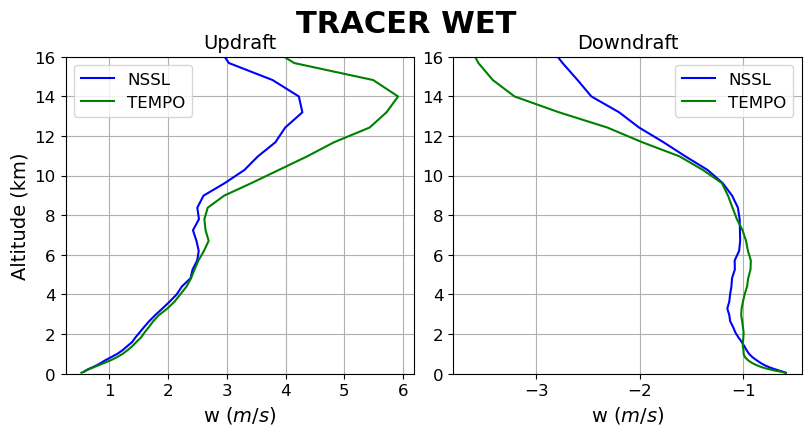

In [75]:
if plotting:
    varName = "w"; units = "m/s"; multiplier = 1
    fig = PlotUpdraftDowndraftPlots_V3(varName,units,multiplier)
    # SaveFigure(fig, varName+"_line_vertical")

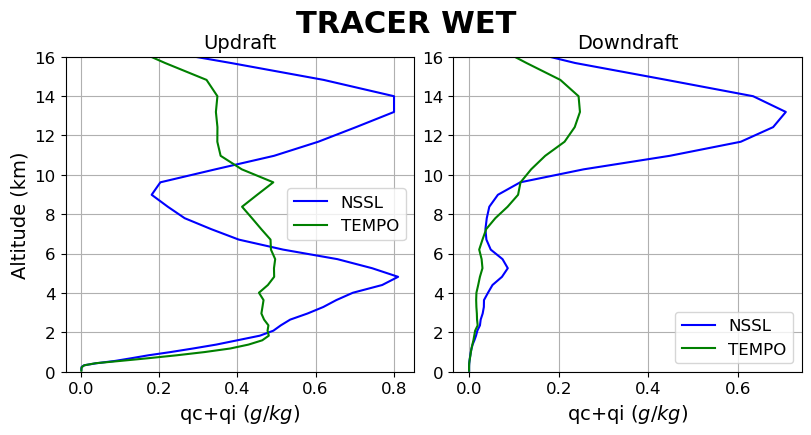

In [76]:
if plotting:
    varName = 'qc+qi'; units = "g/kg"; multiplier = 1e3
    fig = PlotUpdraftDowndraftPlots_V3(varName,units,multiplier)
    # SaveFigure(fig, varName+"_line_vertical")

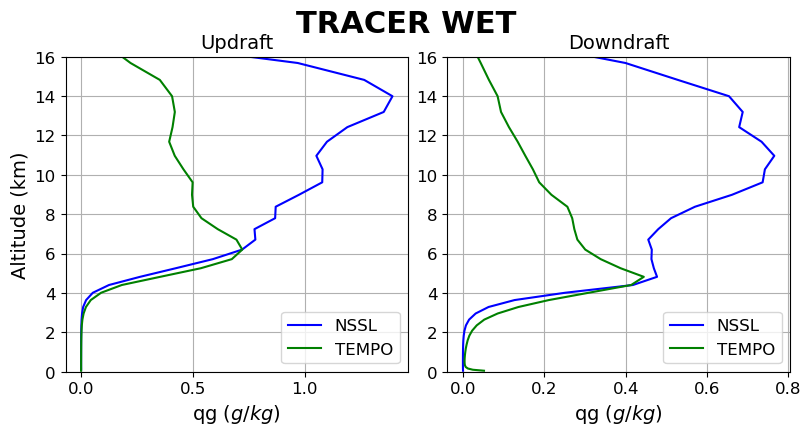

In [78]:
if plotting:
    varName = 'qg'; units = "g/kg"; multiplier = 1e3
    fig = PlotUpdraftDowndraftPlots_V3(varName,units,multiplier)
    SaveFigure(fig, varName+"_line_vertical")

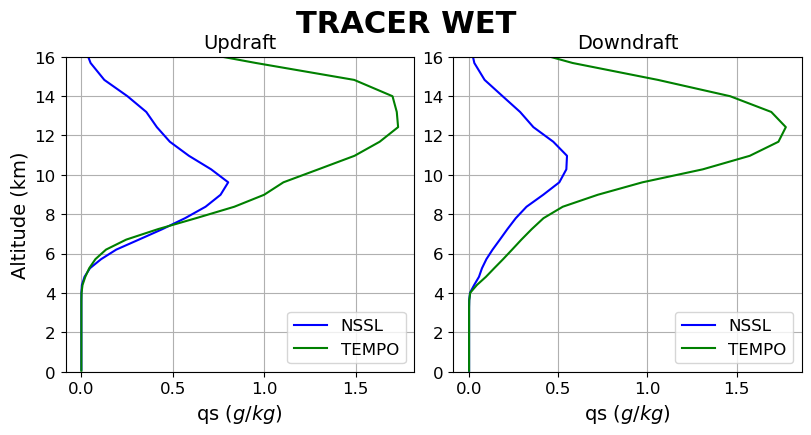

In [79]:
if plotting:
    varName = 'qs'; units = "g/kg"; multiplier = 1e3
    fig = PlotUpdraftDowndraftPlots_V3(varName,units,multiplier)
    SaveFigure(fig, varName+"_line_vertical")

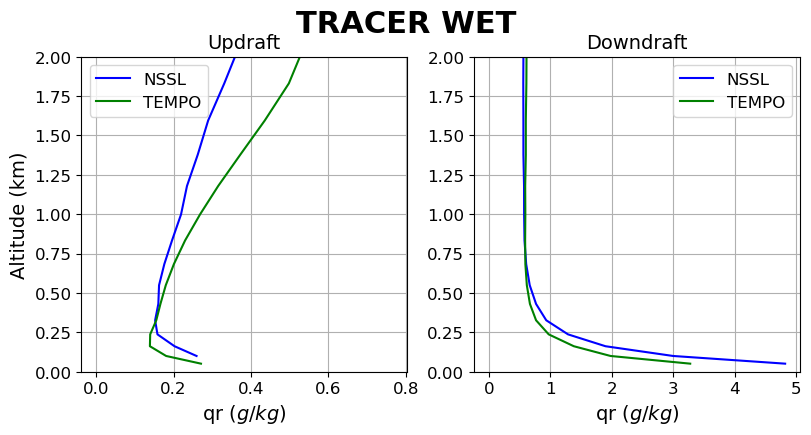

In [80]:
if plotting:
    varName = 'qr'; units = "g/kg"; multiplier = 1e3
    fig = PlotUpdraftDowndraftPlots_V3(varName,units,multiplier)
    SaveFigure(fig, varName+"_line_vertical")

In [ ]:
####################################
#PLOTTING ALL SIMULATIONS

import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 900

plotting = False #keep false when job array is running
# plotting = True

In [ ]:
def GetFigureFilePath(region,case,spinup_hours,
                      varName="w",plotType="line",
                      extension="png"):
    # --- Define output subdirectory ---
    inputSubDirectory = f"{region}_{case}_{spinup_hours}hrs"
    load_dir = os.path.join(outputPlottingDirectory, inputSubDirectory)
    # --- File path ---
    fileName = f"UpdraftAreaAverages_HydrometeorConditions_Interpolation_{varName}_{plotType}"
    inputFilePath = os.path.join(
        load_dir,
        f"{fileName}.{extension}"
    )
    return inputFilePath

def GetFilePaths(varName="w",
                 plotType="line"):
    caseList = ConsolidateFigures_CLASS.GetCaseList()
    filePaths = []
    for region, case, spinup_hours in caseList:
        filePaths.append(GetFigureFilePath(region,case,spinup_hours,
                                           varName,plotType))
    return filePaths

if plotting:
    sys.path.append(os.path.join(DirectoryManager.mainCodeDirectory,"DataAnalysis"))
    from CLASSES_Plotting import ConsolidateFigures_CLASS

In [ ]:
if plotting:
    varName="w"; plotType="line"
    filePaths = GetFilePaths(varName,plotType)
    
    fig = ConsolidateFigures_CLASS.AssembleImageGrid(filePaths=filePaths,
                                                     nrows=3,ncols=2,
                                                     figsize=(5, 4),
                                                     wspace=0.005,hspace=0.005,
                                                     dpi=900)
    ConsolidateFigures_CLASS.SaveCombinedFigure(fig,dpi=900, saveDirectory=outputPlottingDirectory,fileName=dataType+f"_{varName}_{plotType}")
fig

In [ ]:
if plotting:
    varName="w"; plotType="line_vertical"
    filePaths = GetFilePaths(varName,plotType)
    
    fig = ConsolidateFigures_CLASS.AssembleImageGrid(filePaths=filePaths,
                                                     nrows=3,ncols=2,
                                                     figsize=(8, 5),
                                                     wspace=0.005,hspace=0.005,
                                                     dpi=900)
    ConsolidateFigures_CLASS.SaveCombinedFigure(fig,dpi=900, saveDirectory=outputPlottingDirectory,fileName=dataType+f"_{varName}_{plotType}")

In [ ]:
if plotting:
    varName="qc+qi"; plotType="line_vertical"
    filePaths = GetFilePaths(varName,plotType)
    
    fig = ConsolidateFigures_CLASS.AssembleImageGrid(filePaths=filePaths,
                                                     nrows=3,ncols=2,
                                                     figsize=(8, 5),
                                                     wspace=0.005,hspace=0.005,
                                                     dpi=900)
    ConsolidateFigures_CLASS.SaveCombinedFigure(fig,dpi=900, saveDirectory=outputPlottingDirectory,fileName=dataType+f"_{varName}_{plotType}")